``AAPredPlot().predict_group(data, kind=...)`` is the single entry point for across-samples prediction figures: ``kind`` selects the renderer and ``data`` is its input. We first fit an ``AAPred`` and score the whole group to visualize (see [Breimann25]_):

**``predict_group`` = the global (across-proteins) view** of per-protein prediction scores. Pick the ``kind``:

- ``'hist'`` — score distribution, class-separated (``labels``) or confidence-banded (``band=True``).
- ``'ranking'`` — ranked candidates (horizontal bars).
- ``'rank_scatter'`` — per-protein rank scatter (max score vs rank, colored by group).
- ``'scatter'`` — two-predictor agreement.
- ``'cutoff'`` — survival curve over a score threshold.
- ``'clustermap'`` — samples clustered by explanation similarity.

Contrast with ``predict_sample`` (one protein along its sequence) and ``eval`` (model comparison).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity
aa.plot_settings()

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))
aapred = aa.AAPred(df_feat=df_feat, random_state=42).fit(X, labels)
aapred_plot = aa.AAPredPlot()

# Per-protein scores for the group plots
scores = aapred.predict(df_seq, level="sequence")["score"].to_numpy()

/Users/stephanbreimann/Programming/1Packages/wt-predgroup-enh/aaanalysis/feature_engineering/_backend/cpp_run.py:164: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


**Score histogram.** ``kind='hist'`` separates the score distribution by class (``labels``), with ``bins``, decision ``thresholds`` and a per-class ``dict_color``:

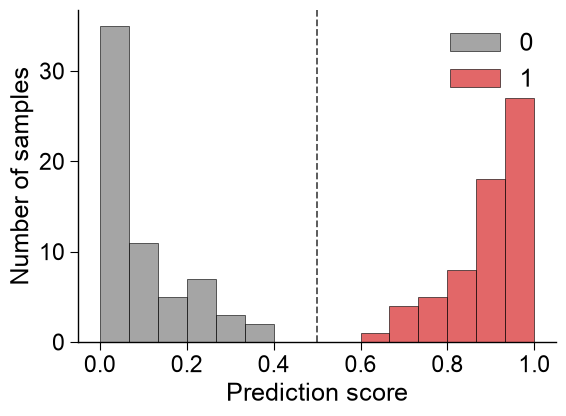

In [2]:
aapred_plot.predict_group(data=scores, kind="hist", labels=labels, bins=15, thresholds=[0.5],
                           dict_color={1: "tab:red", 0: "tab:gray"}, figsize=(6, 4.5),
                           xlabel="Prediction score", ylabel="Number of samples")
plt.tight_layout()
plt.show()

**Confidence-banded histogram.** When scoring *unlabeled* candidates there is no class to separate by, so ``band=True`` instead colors each bar by the confidence band it falls into (delimited by ``thresholds``). Band colors are sampled from ``cmap`` unless an explicit ``colors`` list (one per band, low to high score) is given:

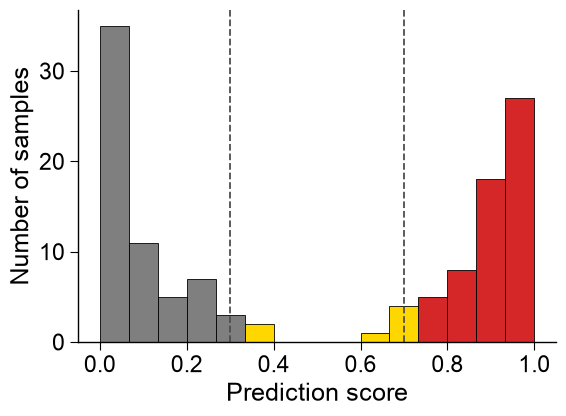

In [3]:
# Same scores, colored by confidence band (no labels): low / medium / high, split at 0.3 and 0.7.
aapred_plot.predict_group(data=scores, kind="hist", band=True, thresholds=[0.3, 0.7], bins=15,
                           colors=["tab:gray", "gold", "tab:red"], figsize=(6, 4.5),
                           xlabel="Prediction score", ylabel="Number of samples")
plt.tight_layout()
plt.show()

**Survival curve.** ``kind='cutoff'`` shows the percentage of samples scoring at or above each cutoff (``n_steps`` controls the resolution):

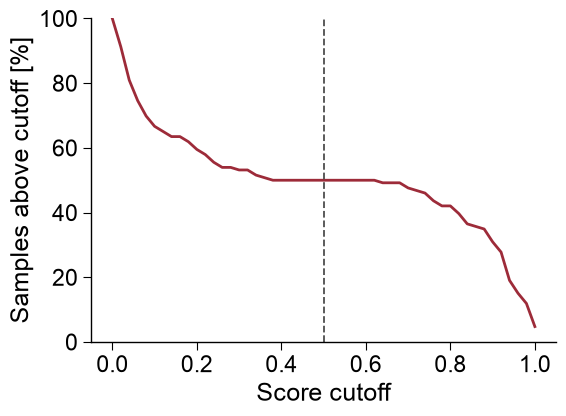

In [4]:
aapred_plot.predict_group(data=scores, kind="cutoff", n_steps=51, thresholds=[0.5],
                           figsize=(6, 4.5), xlabel="Score cutoff",
                           ylabel="Samples above cutoff [%]")
plt.tight_layout()
plt.show()

**Grouped survival curve.** Passing ``labels`` draws one survival curve per group over a common cutoff grid (colored by ``dict_color``) — comparing how each class clears a score threshold:

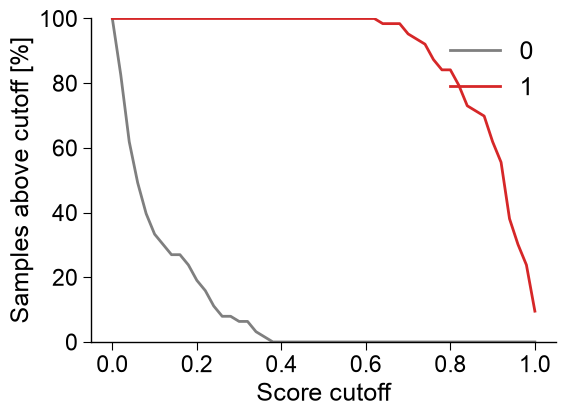

In [5]:
aapred_plot.predict_group(data=scores, kind="cutoff", labels=labels,
                          dict_color={1: "tab:red", 0: "tab:gray"}, n_steps=51,
                          figsize=(6, 4.5), xlabel="Score cutoff",
                          ylabel="Samples above cutoff [%]")
plt.tight_layout()
plt.show()

**Two-predictor agreement.** ``kind='scatter'`` compares two predictors per sample; ``data`` is the x-axis and the required ``scores_y`` is the y-axis, with the ``y = x`` ``diagonal``, ``marker_size`` and ``dict_color``:

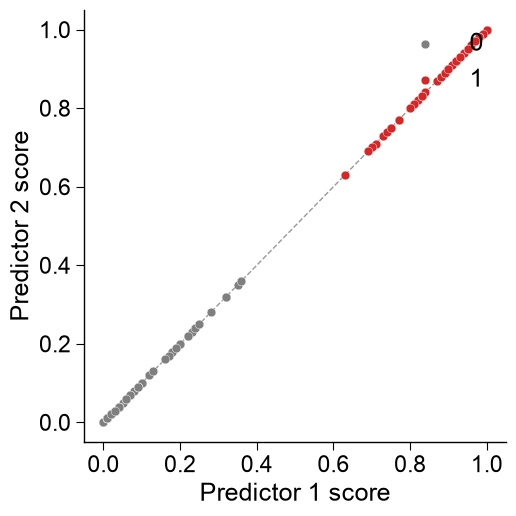

In [6]:
scores_y = aapred.predict(df_seq, level="sequence",
                          list_parts=["tmd", "jmd_n_tmd_n", "tmd_c_jmd_c"])["score"].to_numpy()
aapred_plot.predict_group(data=scores, kind="scatter", scores_y=scores_y, labels=labels,
                           dict_color={1: "tab:red", 0: "tab:gray"}, marker_size=40, diagonal=True,
                           xlabel="Predictor 1 score", ylabel="Predictor 2 score")
plt.tight_layout()
plt.show()

**Ranked candidates.** ``kind='ranking'`` ranks samples as horizontal bars colored by class, reading columns by name (``col_name``, ``col_score``, ``col_group``, ``col_std``) with ``colors``, confidence ``cutoffs``, ``top_n`` and ``ascending`` order:

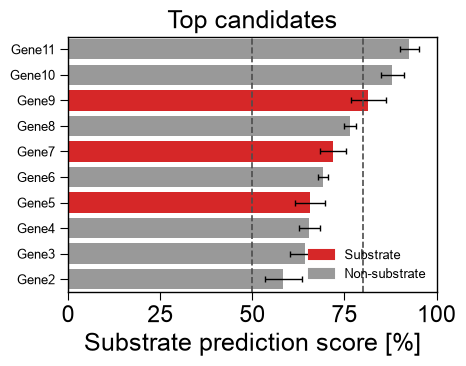

In [7]:
rng = np.random.RandomState(0)
df_rank = pd.DataFrame({
    "name":  [f"Gene{i}" for i in range(12)],
    "score": np.sort(rng.uniform(30, 95, 12)),
    "group": rng.choice(["Substrate", "Non-substrate"], 12),
    "std":   rng.uniform(1, 5, 12),
})
aapred_plot.predict_group(data=df_rank, kind="ranking", col_name="name", col_score="score",
                           col_group="group", col_std="std",
                           colors={"Substrate": "tab:red", "Non-substrate": "0.6"},
                           cutoffs=(50, 80), top_n=10, ascending=False, figsize=(5, 4),
                           xlabel="Substrate prediction score [%]", title="Top candidates")
plt.tight_layout()
plt.show()

**Faceted ranking.** ``panel_col`` splits the ranking into one panel per distinct value of that column, drawn side by side (here one panel per ``group``) — the multi-panel candidate leaderboard in a single call:

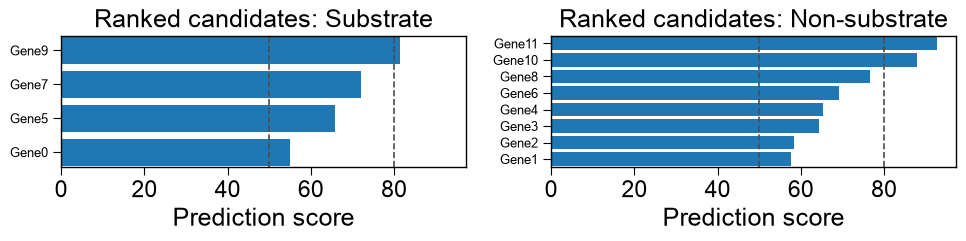

In [8]:
aapred_plot.predict_group(data=df_rank, kind="ranking", col_name="name", col_score="score",
                          panel_col="group",
                          colors={"Substrate": "tab:red", "Non-substrate": "0.6"},
                          cutoffs=(50, 80), title="Ranked candidates")
plt.tight_layout()
plt.show()

**Per-protein rank scatter.** ``kind='rank_scatter'`` is the standard sanity check for a deployed per-protein predictor: proteins are ranked by their maximum ``col_score`` (x-axis = rank, y-axis = score) and colored by ``col_group``. ``group_order`` fixes the color/legend order, ``dict_color`` overrides the canonical group colors (``substrate`` / ``non-substrate`` / ``hold-out`` default to the locked sample palette), ``thresholds`` draws horizontal cut-off lines, and ``marker_size`` sizes the points. This is the *population* view; contrast ``kind='ranking'`` above, which draws one horizontal bar per candidate.

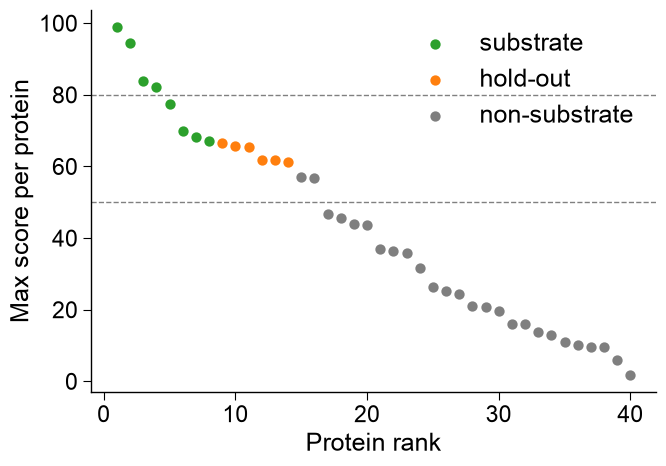

In [9]:
# Per-protein max score + group -> the deployed-predictor rank scatter (a different figure
# than kind="ranking": one point per protein, ranked, not one bar per candidate).
df_prot = pd.DataFrame({
    "score": np.sort(rng.uniform(0, 100, 40))[::-1],
    "group": ["substrate"] * 8 + ["hold-out"] * 6 + ["non-substrate"] * 26,
})
aapred_plot.predict_group(data=df_prot, kind="rank_scatter", col_score="score", col_group="group",
                          group_order=["substrate", "hold-out", "non-substrate"],
                          dict_color={"substrate": "tab:green", "hold-out": "tab:orange",
                                      "non-substrate": "tab:gray"},
                          thresholds=[50, 80], marker_size=35,
                          xlabel="Protein rank", ylabel="Max score per protein")
plt.tight_layout()
plt.show()

**Explanation similarity.** ``kind='clustermap'`` clusters samples by *why* the model scores them, the correlation of their per-sample importance vectors, with ``names``, class ``labels`` / ``colors``, ``cmap``, ``cbar_label`` and ``title`` (``data`` is the importance matrix; the clustermap owns its figure, so ``ax`` is ignored):

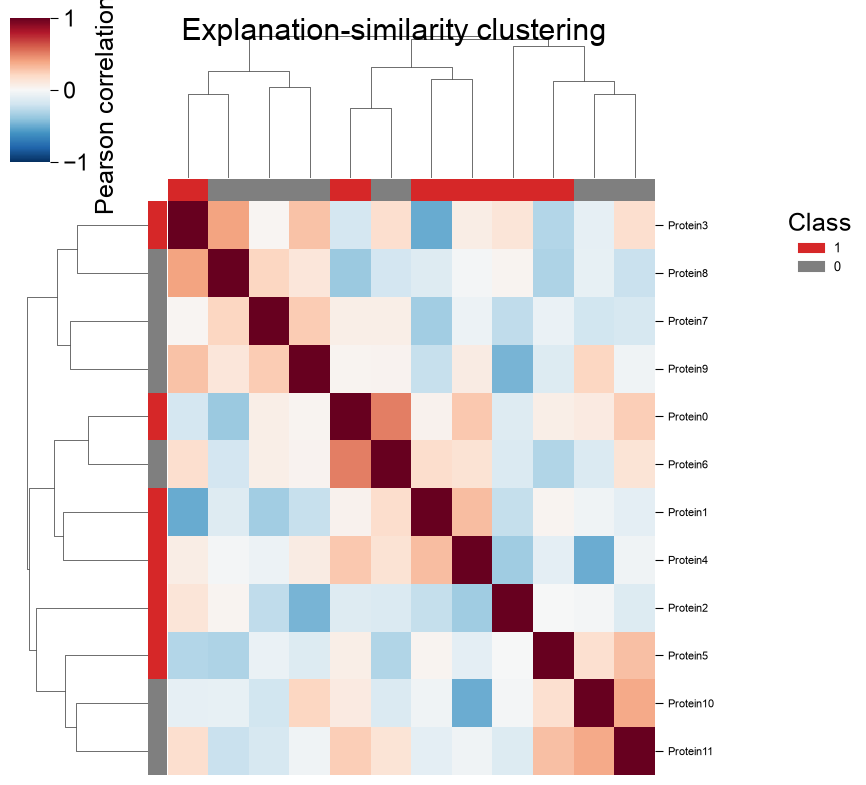

In [10]:
block_a = rng.normal(0.6, 0.2, size=(6, 20))
block_b = rng.normal(-0.6, 0.2, size=(6, 20))
data = np.vstack([block_a, block_b])
imp_labels = np.array([1] * 6 + [0] * 6)
names = [f"Protein{i}" for i in range(12)]
aapred_plot.predict_group(data=data, kind="clustermap", names=names, labels=imp_labels,
                           colors={1: "tab:red", 0: "tab:gray"}, cmap="RdBu_r", figsize=(8, 8),
                           cbar_label="Pearson correlation (r)",
                           title="Explanation-similarity clustering")
plt.show()

**Two annotation tracks.** A distinct ``labels_row`` adds a second sidebar (row/left) alongside the ``labels`` sidebar (column/top) — e.g. class on top and a confidence band on the left — each with its own colors (``colors`` / ``colors_row``) and legend title (``legend_title`` / ``legend_title_row``). When ``labels_row`` is omitted the ``labels`` annotation mirrors onto both sidebars:

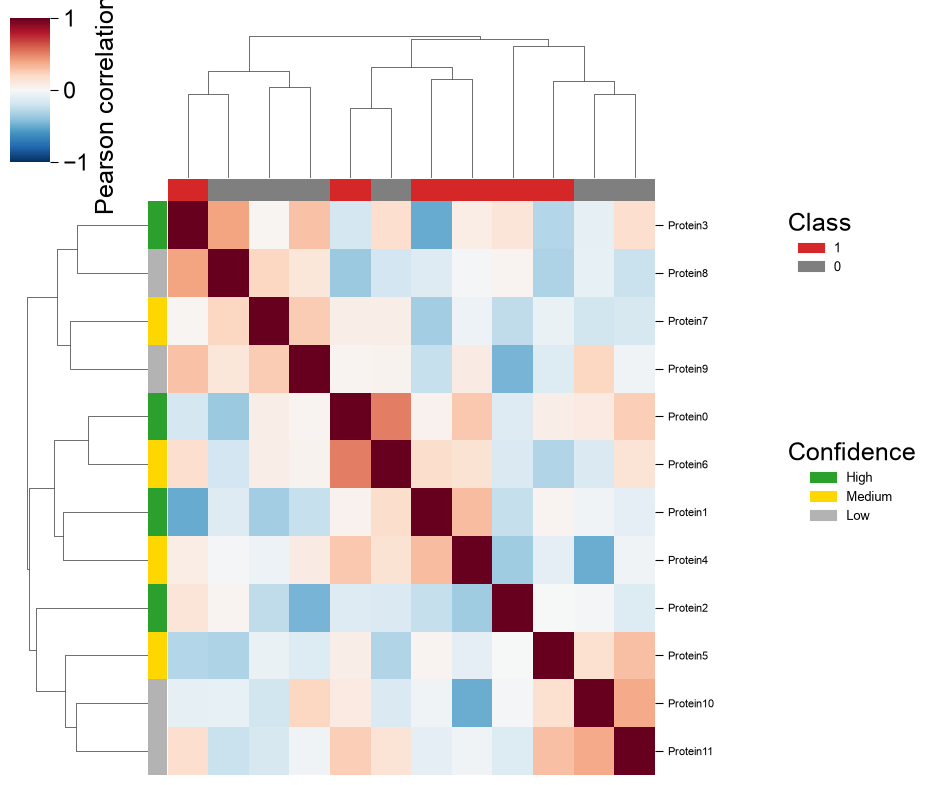

In [11]:
conf = np.array(["High"] * 4 + ["Medium"] * 4 + ["Low"] * 4)
aapred_plot.predict_group(data=data, kind="clustermap", names=names,
                          labels=imp_labels, labels_row=conf,
                          colors={1: "tab:red", 0: "tab:gray"},
                          colors_row={"High": "tab:green", "Medium": "gold", "Low": "0.7"},
                          legend_title="Class", legend_title_row="Confidence",
                          cmap="RdBu_r", figsize=(8, 8),
                          cbar_label="Pearson correlation (r)")
plt.show()